In [1]:
# install packages
%pip install -q nltk transformers scikit-learn matplotlib torch numpy

# Import libraries
import nltk
import numpy as np


# Download NLTK treebank dataset
nltk.download('treebank', quiet=True)
from nltk.corpus import treebank

Note: you may need to restart the kernel to use updated packages.


In [2]:
# each sentence is a list of (word, pos_tag) tuples
sentences = treebank.tagged_sents()

# first sentence from the treebank corpus
first_sentence = sentences[0]
print(first_sentence)

# separate the words and the corresponding POS tags
words = []
pos_order = []
for word, pos in first_sentence:
    words.append(word)
    pos_order.append(pos)

# printing sentence and order of POS tags --> visualization of how the data looks like
print("Sentence:", " ".join(words))
print("POS Order:", " ".join(pos_order))

[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')]
Sentence: Pierre Vinken , 61 years old , will join the board as a nonexecutive director Nov. 29 .
POS Order: NNP NNP , CD NNS JJ , MD VB DT NN IN DT JJ NN NNP CD .


In [4]:
# Prepare data for CSV with sentence length
import csv
csv_data = []
for sentence in sentences:
    words = [word for word, pos in sentence]
    sentence_length = len(words)  # Calculate the token count
    csv_data.append({"Sentence": " ".join(words), "Length": sentence_length})

# Write to CSV file
csv_file = "treebank_data_with_length.csv"
with open(csv_file, mode="w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=["Sentence", "Length"])
    writer.writeheader()
    writer.writerows(csv_data)

print(f"Treebank data with sentence lengths has been saved to {csv_file}")


Treebank data with sentence lengths has been saved to treebank_data_with_length.csv


[18, 13, 27, 41, 35, 27, 37, 12, 16, 10, 22, 26, 23, 38, 22, 24, 17, 27, 24, 40, 27, 46, 55, 22, 18, 15, 23, 16, 36, 25, 32, 16, 10, 22, 37, 16, 26, 25, 19, 38, 34, 24, 16, 23, 21, 12, 29, 20, 18, 28, 29, 17, 12, 29, 20, 29, 15, 16, 15, 20, 26, 20, 20, 31, 19, 29, 19, 20, 14, 32, 4, 18, 19, 42, 32, 26, 5, 30, 16, 22, 29, 16, 24, 20, 14, 38, 24, 22, 17, 30, 33, 37, 27, 23, 22, 25, 12, 32, 31, 47, 22, 13, 52, 12, 25, 38, 49, 30, 27, 13, 25, 22, 15, 43, 44, 58, 21, 21, 58, 31, 14, 13, 32, 5, 30, 33, 42, 13, 27, 41, 24, 47, 27, 34, 39, 47, 31, 23, 22, 25, 21, 20, 32, 21, 19, 30, 21, 21, 23, 33, 19, 16, 28, 29, 20, 16, 22, 39, 17, 12, 15, 15, 31, 29, 35, 15, 36, 25, 53, 37, 25, 38, 27, 24, 18, 22, 11, 33, 32, 29, 14, 17, 25, 32, 19, 48, 25, 35, 39, 11, 15, 10, 16, 37, 13, 43, 22, 39, 24, 13, 58, 6, 25, 24, 16, 12, 16, 13, 19, 9, 16, 6, 47, 41, 32, 29, 41, 41, 30, 20, 38, 22, 41, 12, 14, 45, 52, 19, 33, 23, 26, 21, 28, 27, 33, 16, 31, 13, 18, 43, 16, 28, 16, 15, 9, 22, 34, 13, 23, 11, 33, 20

,Shortest Sentences,Word Count (Shortest),Longest Sentences,Word Count (Longest)
0,@,1,"The following *ICH*-4 were barred *-3 or , whe...",271
1,Virginia :,2,"Andrew Derel Adams , Killeen , Texas , fined *...",128
2,Virginia :,2,"Charles D. Phipps Sr. , Hermitage , Pa. , fine...",125
3,Virginia :,2,"Victor Stanley Fishman , Longwood , Fla. , fin...",110
4,Virginia :,2,But other than the fact that besuboru is playe...,92


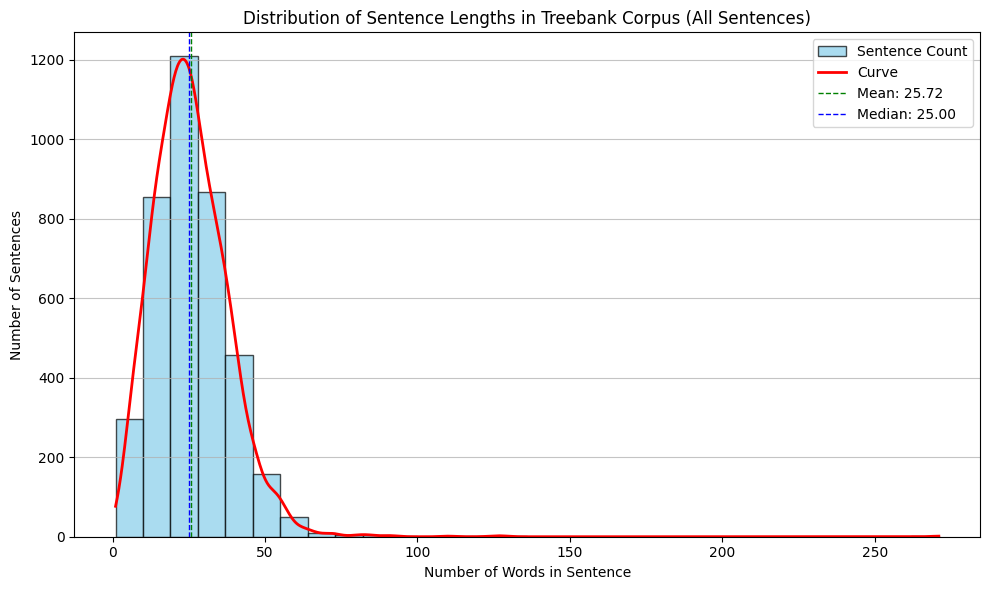

In [36]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

# Extract sentences and their word counts
sentences_text = [" ".join(word for word, tag in sentence) for sentence in sentences]
sentence_lengths = [len(sentence) for sentence in sentences]
print(sentence_lengths)

plt.figure(figsize=(10, 6))

# Create histogram with absolute counts rather than density
plt.hist(sentence_lengths, bins=30, color='skyblue', edgecolor='black', 
         alpha=0.7, label='Sentence Count')

# Add a kernel density estimation curve
kde = stats.gaussian_kde(sentence_lengths)
x_values = np.linspace(min(sentence_lengths), max(sentence_lengths), 1000)
plt.plot(x_values, kde(x_values) * len(sentence_lengths) * (max(sentence_lengths) - min(sentence_lengths)) / 30, 
         'r-', linewidth=2, label='Curve')

# Add mean and median lines
plt.axvline(np.mean(sentence_lengths), color='green', linestyle='dashed', 
           linewidth=1, label=f'Mean: {np.mean(sentence_lengths):.2f}')
plt.axvline(np.median(sentence_lengths), color='blue', linestyle='dashed',
           linewidth=1, label=f'Median: {np.median(sentence_lengths):.2f}')

plt.title('Distribution of Sentence Lengths in Treebank Corpus (All Sentences)')
plt.xlabel('Number of Words in Sentence')
plt.ylabel('Number of Sentences')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.tight_layout()


longest_lengths = sorted(sentence_lengths, reverse=True)[:5]
longest_indices = [sentence_lengths.index(length) for length in longest_lengths]
sentence_length_variance = round(np.var(sentence_lengths),4)

print(f"Total number of sentences: {len(sentences_text)}")
print(f"Average sentence length: {np.mean(sentence_lengths):.2f} words")
print(f"Variance of sentence lengths: {sentence_length_variance}")


shortest_lengths = sorted(sentence_lengths)[:5]
shortest_indices = [sentence_lengths.index(length) for length in shortest_lengths]
shortest_sentences = [sentences_text[idx] for idx in shortest_indices]

# Prepare data for table
data = {
    'Shortest Sentences': [s[:50] + '...' if len(s) > 50 else s for s in shortest_sentences],
    'Word Count (Shortest)': shortest_lengths,
    'Longest Sentences': [s[:50] + '...' if len(s) > 50 else s for s in [sentences_text[idx] for idx in longest_indices]],
    'Word Count (Longest)': longest_lengths
}

# Create and display the table
sentence_table = pd.DataFrame(data)
display(sentence_table)

In [34]:
sentence_length_variance = np.var(sentence_lengths)
print(f"Variance of sentence lengths: {sentence_length_variance}")

Variance of sentence lengths: 165.55686294681593
